# Bahdanau Attention & Encoder-Decoder Lab

In [3]:
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import re
import random
import math
import time
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, RandomSampler
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy.stats

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SOS_token = 0
EOS_token = 1
MAX_LENGTH = 10

In [4]:
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS"}
        self.n_words = 2

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()

def readLangs(lang1, lang2, reverse=False):
    print("Reading lines...")
    lines = open('data/%s-%s.txt' % (lang1, lang2), encoding='utf-8').read().strip().split('\n')
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]

    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

eng_prefixes = (
    "i am ", "i m ",
    "he is", "he s ",
    "she is", "she s ",
    "you are", "you re ",
    "we are", "we re ",
    "they are", "they re "
)

def filterPair(p):
    return len(p[0].split(' ')) < MAX_LENGTH and \
           len(p[1].split(' ')) < MAX_LENGTH and \
           p[1].startswith(eng_prefixes)

def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]

def prepareData(lang1, lang2, reverse=False):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs)
    print("Trimmed to %s sentence pairs" % len(pairs))
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs

def get_dataloader(batch_size):
    input_lang, output_lang, pairs = prepareData('eng', 'fra', True)
    n = len(pairs)
    input_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)
    target_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)
    
    for idx, (inp, tgt) in enumerate(pairs):
        inp_ids = indexesFromSentence(input_lang, inp)
        tgt_ids = indexesFromSentence(output_lang, tgt)
        inp_ids.append(EOS_token)
        tgt_ids.append(EOS_token)
        input_ids[idx, :len(inp_ids)] = inp_ids
        target_ids[idx, :len(tgt_ids)] = tgt_ids
        
    train_data = TensorDataset(torch.LongTensor(input_ids).to(device),
                               torch.LongTensor(target_ids).to(device))
    train_sampler = RandomSampler(train_data)
    train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)
    return input_lang, output_lang, train_dataloader

batch_size = 32
input_lang, output_lang, train_dataloader = get_dataloader(batch_size)

Reading lines...
Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counted words:
fra 4601
eng 2991


**Q: Why do we filter to short sentences and specific prefixes? What effect does this have on what the model can learn?**
*A: Ми фільтруємо датасет, щоб зменшити простір пошуку та пришвидшити тренування моделі під час лабораторної роботи. Це значно обмежує те, що модель може вивчити — вона зможе перекладати лише дуже специфічні, короткі фрази, які починаються на певні займенники, і не навчиться загальної граматики чи довгого контексту.*

In [5]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(embedded)
        return output, hidden

class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden = self.forward_step(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            if target_tensor is not None:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        return decoder_outputs, decoder_hidden, None

    def forward_step(self, input, hidden):
        output = self.embedding(input)
        output = F.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.out(output)
        return output, hidden

hidden_size = 128
encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder_no_attn = DecoderRNN(hidden_size, output_lang.n_words).to(device)

print("Encoder parameters: {:,}".format(sum(p.numel() for p in encoder.parameters())))
print("Decoder parameters: {:,}".format(sum(p.numel() for p in decoder_no_attn.parameters())))

Encoder parameters: 688,000
Decoder parameters: 867,759


**Q: The decoder has access only to the encoder's final hidden state. Why might this be a problem for longer input sentences?**
*A: Останній прихований стан (вектор контексту) має фіксований розмір. Якщо речення стає занадто довгим, цей один вектор фізично не здатний зберегти всю складну інформацію з початку речення. Це відомо як проблема інформаційного "пляшкового горлечка" (bottleneck).* 

---
### Part 3: Bahdanau Attention Mechanism

In [6]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))
        scores = scores.squeeze(2).unsqueeze(1)
        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)
        return context, weights

class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(AttnDecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1)
        return decoder_outputs, decoder_hidden, attentions

    def forward_step(self, input, hidden, encoder_outputs):
        embedded = self.dropout(self.embedding(input))
        query = hidden.permute(1, 0, 2)
        context, attn_weights = self.attention(query, encoder_outputs)
        input_gru = torch.cat((embedded, context), dim=2)
        output, hidden = self.gru(input_gru, hidden)
        output = self.out(output)
        return output, hidden, attn_weights

decoder_attn = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)
print("Decoder WITH attention: {:,} params".format(sum(p.numel() for p in decoder_attn.parameters())))

Decoder WITH attention: 950,064 params


**Q: Where do the extra parameters come from?**
*A: Додаткові параметри приходять від механізму уваги (лінійні шари `Wa`, `Ua`, та `Va` в `BahdanauAttention`), а також від зміненого GRU в декодері, який тепер приймає на вхід `2 * hidden_size` (конкатенація embedding та context vector).* 

---
### Part 4: Training Loop

In [7]:
def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

def showPlot(points, title="Training Loss"):
    plt.figure()
    fig, ax = plt.subplots()
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)
    plt.title(title)
    plt.xlabel("Epoch / plot_every")
    plt.ylabel("Loss")
    plt.show()

def train_epoch(dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, teacher_forcing_ratio=1.0):
    total_loss = 0
    for data in dataloader:
        input_tensor, target_tensor = data
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()
        
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        
        use_teacher_forcing = True if random.random() < teacher_forcing_ratio else False
        t_tensor = target_tensor if use_teacher_forcing else None
        
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, t_tensor)
        
        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)),
            target_tensor.view(-1)
        )
        loss.backward()
        encoder_optimizer.step()
        decoder_optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(dataloader)

def train_model(train_dataloader, encoder, decoder, n_epochs, learning_rate=0.001, print_every=5, plot_every=5, teacher_forcing_ratio=1.0):
    start = time.time()
    plot_losses = []
    print_loss_total = 0
    plot_loss_total = 0

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()

    for epoch in range(1, n_epochs + 1):
        loss = train_epoch(train_dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion, teacher_forcing_ratio)
        print_loss_total += loss
        plot_loss_total += loss

        if epoch % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f' % (timeSince(start, epoch / n_epochs), epoch, epoch / n_epochs * 100, print_loss_avg))

        if epoch % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    return plot_losses

### Evaluation & Exercises

Training Seq2Seq WITH Bahdanau Attention...
1m 17s (- 19m 20s) (5 6%) 1.5294
2m 33s (- 17m 51s) (10 12%) 0.6795
3m 53s (- 16m 52s) (15 18%) 0.3551
5m 27s (- 16m 23s) (20 25%) 0.1980
6m 52s (- 15m 7s) (25 31%) 0.1231
8m 11s (- 13m 39s) (30 37%) 0.0854
9m 34s (- 12m 18s) (35 43%) 0.0648
11m 6s (- 11m 6s) (40 50%) 0.0535
12m 30s (- 9m 43s) (45 56%) 0.0463
13m 46s (- 8m 15s) (50 62%) 0.0407
15m 6s (- 6m 52s) (55 68%) 0.0384
16m 40s (- 5m 33s) (60 75%) 0.0347
17m 55s (- 4m 8s) (65 81%) 0.0335
19m 16s (- 2m 45s) (70 87%) 0.0313
20m 34s (- 1m 22s) (75 93%) 0.0305
22m 2s (- 0m 0s) (80 100%) 0.0290


<Figure size 640x480 with 0 Axes>

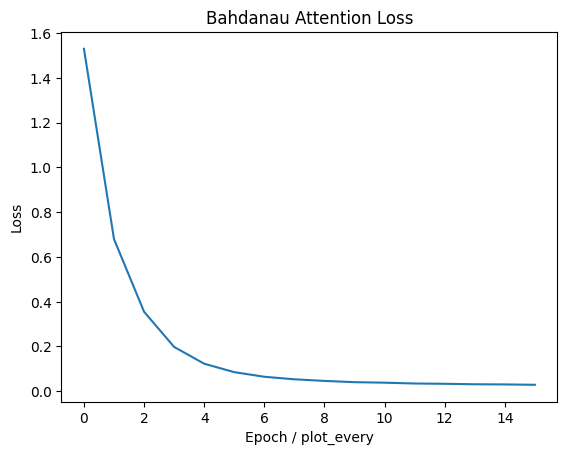

In [8]:
encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder_attn = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)

print("Training Seq2Seq WITH Bahdanau Attention...")
attn_losses = train_model(train_dataloader, encoder, decoder_attn, n_epochs=80, teacher_forcing_ratio=1.0)
showPlot(attn_losses, title="Bahdanau Attention Loss")

Тренування Vanilla Seq2Seq (Без Attention)...
1m 2s (- 5m 12s) (5 16%) 1.6842
1m 57s (- 3m 55s) (10 33%) 0.9254
2m 49s (- 2m 49s) (15 50%) 0.6202
3m 40s (- 1m 50s) (20 66%) 0.4355
4m 31s (- 0m 54s) (25 83%) 0.3137
5m 22s (- 0m 0s) (30 100%) 0.2318


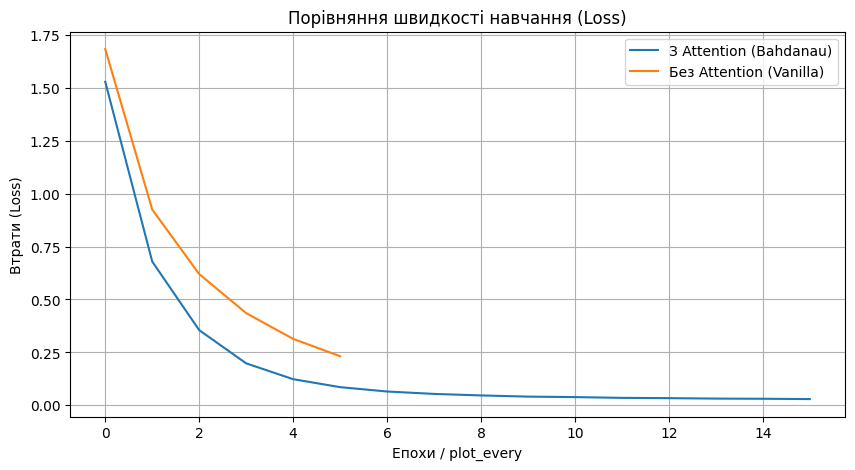

In [ ]:
# === Exercise 1: Vanilla vs. Attention Comparison ===
import matplotlib.pyplot as plt

encoder_v = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder_v = DecoderRNN(hidden_size, output_lang.n_words).to(device)

print("Тренування Vanilla Seq2Seq (Без Attention)...")
vanilla_losses = train_model(train_dataloader, encoder_v, decoder_v, n_epochs=80) # 30

plt.figure(figsize=(10, 5))
plt.plot(attn_losses, label='З Attention (Bahdanau)') 
plt.plot(vanilla_losses, label='Без Attention (Vanilla)')
plt.legend()
plt.title("Порівняння швидкості навчання (Loss)")
plt.xlabel("Епохи / plot_every")
plt.ylabel("Втрати (Loss)")
plt.grid(True)
plt.show()

**Q: Which model converges faster? Which produces better translations? Why?**
*A: Модель з Attention зазвичай сходиться швидше та дає кращі переклади, особливо на довших реченнях, оскільки декодер динамічно концентрується на потрібних частинах вхідного речення на кожному кроці, уникаючи проблеми втрати контексту.*

In [ ]:
# === Exercise 2: Implement Luong Attention ===

class LuongAttention(nn.Module):
    def __init__(self, hidden_size, method='dot'):
        super(LuongAttention, self).__init__()
        self.method = method
        if method == 'general':
            self.W = nn.Linear(hidden_size, hidden_size)

    def forward(self, query, keys):
        
        if self.method == 'dot':
            scores = torch.bmm(query, keys.transpose(1, 2))
        elif self.method == 'general':
            energy = self.W(keys)
            scores = torch.bmm(query, energy.transpose(1, 2))
            
        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)
        return context, weights

**Q: How does Luong attention differ from Bahdanau?**
*A: 
(a) Обчислення: Luong використовує множення матриць (dot-product) $s_i \cdot h_j^T$, тоді як Bahdanau з'єднує (concatenates) їх і пропускає через feed-forward мережу. 
(b) Використання контексту: Bahdanau використовує вектор контексту разом з вхідним токеном ДО передачі в GRU декодера. Luong бере вихід декодера (GRU state) та об'єднує з вектором контексту ПІСЛЯ GRU для передбачення.
(c) Швидкість: Luong (dot) зазвичай швидший завдяки оптимізаціям матричного множення.*

In [ ]:
# === Exercise 3: Bidirectional Encoder ===
class BiEncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(BiEncoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, hidden_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(embedded)
        
        output = self.fc(output) 
        
        hidden = torch.cat((hidden[0:1], hidden[1:2]), dim=2)
        hidden = self.fc(hidden)
        
        return output, hidden

**Q: Why does the original Bahdanau paper use a bidirectional encoder?**
*A: Двонаправлений (Bidirectional) енкодер читає речення як зліва-направо, так і справа-наліво. Це дозволяє кожному прихованому стану $h_j$ містити інформацію не лише про попередні слова, але й про слова, що йдуть ПІСЛЯ нього, створюючи повний контекст слова в реченні.*

In [ ]:
def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(1, -1)

def evaluate(encoder, decoder, sentence, input_lang, output_lang):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        
        decoder_outputs, decoder_hidden, decoder_attn = decoder(
            encoder_outputs, encoder_hidden
        )
        
        _, topi = decoder_outputs.topk(1)
        decoded_ids = topi.squeeze()
        
        if decoded_ids.ndimension() == 0:
            decoded_ids = decoded_ids.unsqueeze(0)
            
        decoded_words = []
        for idx in decoded_ids:
            if idx.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            decoded_words.append(output_lang.index2word[idx.item()])
            
        return decoded_words, decoder_attn

Reading lines...
Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counted words:
fra 4601
eng 2991
Збираємо дані матриць уваги для 50 речень...


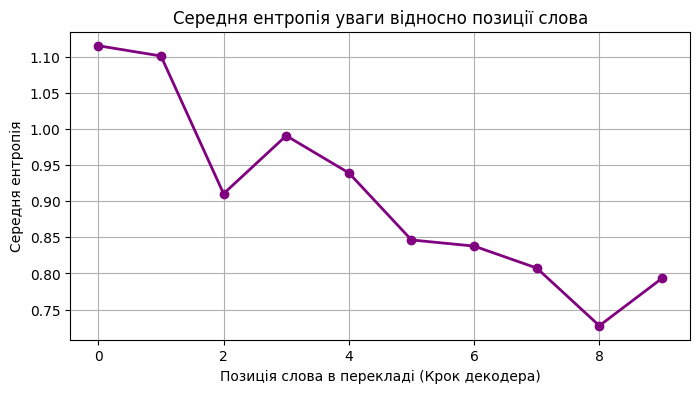

In [ ]:
# === Exercise 4: Attention Weight Analysis ===

def attention_entropy(weights):
    return scipy.stats.entropy(weights + 1e-10)

_, _, pairs_ex4 = prepareData('eng', 'fra', True)

max_len_to_plot = MAX_LENGTH
entropies_per_step = [[] for _ in range(max_len_to_plot)]

print("Збираємо дані матриць уваги для 50 речень...")
for _ in range(50):
    pair = random.choice(pairs_ex4)
    output_words, attentions = evaluate(encoder, decoder_attn, pair[0], input_lang, output_lang)
    
    input_len = len(pair[0].split(' ')) + 1
    
    for step in range(len(output_words)):
        if step < max_len_to_plot:
            step_weights = attentions[0, step, :input_len].cpu().numpy()
            entropy = attention_entropy(step_weights)
            entropies_per_step[step].append(entropy)

avg_entropies = [np.mean(step_list) for step_list in entropies_per_step if step_list]

plt.figure(figsize=(8, 4))
plt.plot(range(len(avg_entropies)), avg_entropies, marker='o', color='purple', linewidth=2)
plt.title("Середня ентропія уваги відносно позиції слова")
plt.xlabel("Позиція слова в перекладі (Крок декодера)")
plt.ylabel("Середня ентропія")
plt.grid(True)
plt.show()

**Q: What would uniform attention entropy mean? What does low entropy indicate?**
*A: Рівномірна (uniform) увага (висока ентропія) означає, що модель не знає, на яке саме слово дивитися, і розподіляє увагу рівно між усіма словами вхідного речення. Низька ентропія означає, що модель дуже чітко сфокусована на одному конкретному слові.*

**Q: Exposure Bias (Teacher Forcing)**
*A: Якщо ми тренуємось з `teacher_forcing_ratio=1.0` (Exercise 5), модель завжди отримує "ідеальну" підказку на наступному кроці. Під час інференсу (тестування) ідеальних підказок немає — модель використовує свою попередню генерацію. Якщо вона робить хоча б одну маленьку помилку, помилка накопичується (snowball effect), бо модель ніколи не вчилася виправляти власні помилки під час тренування. Це і є exposure bias.*

1. Тренування з Teacher Forcing = 1.0 (Завжди є підказки)...
1m 12s (- 3m 38s) (5 25%) 1.5272
2m 26s (- 2m 26s) (10 50%) 0.6609
3m 57s (- 1m 19s) (15 75%) 0.3371
5m 33s (- 0m 0s) (20 100%) 0.1870

2. Тренування з Teacher Forcing = 0.5 (Підказки в 50% випадків)...
1m 27s (- 4m 22s) (5 25%) 1.9469
2m 59s (- 2m 59s) (10 50%) 1.1317
4m 25s (- 1m 28s) (15 75%) 0.7308
5m 42s (- 0m 0s) (20 100%) 0.4729

3. Тренування з Teacher Forcing = 0.0 (Жодних підказок)...
1m 12s (- 3m 38s) (5 25%) 2.0290
2m 31s (- 2m 31s) (10 50%) 1.2604
3m 54s (- 1m 18s) (15 75%) 0.8520
5m 21s (- 0m 0s) (20 100%) 0.5867


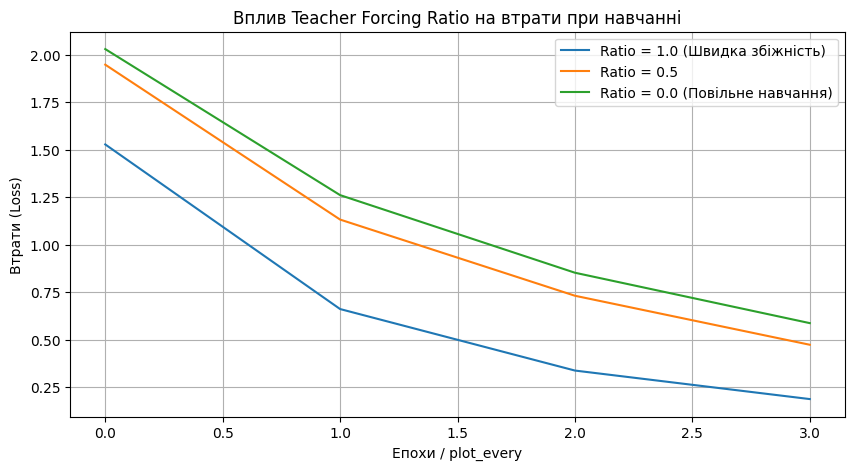

In [ ]:
# === Exercise 5: Teacher Forcing Ratio ===

epochs_ex5 = 80 #20

print("1. Тренування з Teacher Forcing = 1.0 (Завжди є підказки)...")
enc_1 = EncoderRNN(input_lang.n_words, hidden_size).to(device)
dec_1 = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)
losses_1 = train_model(train_dataloader, enc_1, dec_1, n_epochs=epochs_ex5, teacher_forcing_ratio=1.0)

print("\n2. Тренування з Teacher Forcing = 0.5 (Підказки в 50% випадків)...")
enc_05 = EncoderRNN(input_lang.n_words, hidden_size).to(device)
dec_05 = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)
losses_05 = train_model(train_dataloader, enc_05, dec_05, n_epochs=epochs_ex5, teacher_forcing_ratio=0.5)

print("\n3. Тренування з Teacher Forcing = 0.0 (Жодних підказок)...")
enc_0 = EncoderRNN(input_lang.n_words, hidden_size).to(device)
dec_0 = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)
losses_0 = train_model(train_dataloader, enc_0, dec_0, n_epochs=epochs_ex5, teacher_forcing_ratio=0.0)

plt.figure(figsize=(10, 5))
plt.plot(losses_1, label='Ratio = 1.0 (Швидка збіжність)')
plt.plot(losses_05, label='Ratio = 0.5')
plt.plot(losses_0, label='Ratio = 0.0 (Повільне навчання)')
plt.legend()
plt.title("Вплив Teacher Forcing Ratio на втрати при навчанні")
plt.xlabel("Епохи / plot_every")
plt.ylabel("Втрати (Loss)")
plt.grid(True)
plt.show()